In [1]:
import pandas as pd
import numpy as np
import random

# CONFIGURATION
ROWS = 5000

def generate_balanced_row():
    # 1. Base Scenario
    scenario = random.choice([
        "Healthy", "Healthy", "Healthy", # More healthy data is realistic
        "Low Nitrogen", "Low Phosphorus", "Low Potassium",
        "Acidic", "Alkaline", "Dry", "Wet"
    ])

    # 2. Set Distinct Base Ranges (To ensure separation)
    # Healthy Baseline
    n = random.randint(200, 250)
    p = random.randint(40, 60)
    k = random.randint(200, 300)
    ph = random.uniform(6.0, 7.0)
    moist = random.randint(60, 80)
    temp = random.randint(25, 30)
    label = "Healthy"

    # 3. Apply Scenario Logic (Creating the "Signal")
    if scenario == "Low Nitrogen":
        n = random.randint(50, 150) # Clearly lower than 200
        label = "Urea"
    elif scenario == "Low Phosphorus":
        p = random.randint(5, 25)   # Clearly lower than 40
        label = "DAP"
    elif scenario == "Low Potassium":
        k = random.randint(50, 150) # Clearly lower than 200
        label = "MOP"
    elif scenario == "Acidic":
        ph = random.uniform(4.5, 5.5) # Clearly lower than 6.0
        label = "Dolomite"
    elif scenario == "Alkaline":
        ph = random.uniform(7.5, 8.5) # Clearly higher than 7.0
        label = "Sulfur"
    elif scenario == "Dry":
        moist = random.randint(20, 45) # Clearly lower than 60
        label = "Irrigate"
    elif scenario == "Wet":
        moist = random.randint(90, 100)
        label = "Drainage"

    # 4. ADD REALISTIC NOISE (Reduced to prevent total overlap)
    # We use Normal Distribution (Bell Curve)
    n += int(np.random.normal(0, 10)) 
    p += int(np.random.normal(0, 2))
    k += int(np.random.normal(0, 10))
    ph += np.random.normal(0, 0.1)
    moist += int(np.random.normal(0, 3))
    temp += int(np.random.normal(0, 2))

    # 5. Occasional "Human Error" (Reduced to 2%)
    # This prevents 100% accuracy but doesn't ruin the model
    if random.random() < 0.02: 
        label = random.choice(["Healthy", "Urea", "DAP"])

    return [temp, moist, n, p, k, ph, label]

# Generate
print("🔄 Generating 'Sweet Spot' Data...")
data = [generate_balanced_row() for _ in range(ROWS)]
df = pd.DataFrame(data, columns=['Temperature', 'Moisture', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Label'])

# Save as the SAME filename your training script looks for
df.to_csv("realistic_soil_data.csv", index=False)
print(f"✅ Generated {ROWS} rows. Saved to 'realistic_soil_data.csv'.")
print("👉 NOW RE-RUN YOUR 'Professional Grade' TRAINING SCRIPT.")

🔄 Generating 'Sweet Spot' Data...
✅ Generated 5000 rows. Saved to 'realistic_soil_data.csv'.
👉 NOW RE-RUN YOUR 'Professional Grade' TRAINING SCRIPT.


In [2]:
pip install pandas numpy seaborn matplotlib scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


🔄 Loading Data...
   Original Training Count: Counter({np.int64(3): 1185, np.int64(7): 451, np.int64(4): 427, np.int64(0): 426, np.int64(2): 407, np.int64(6): 385, np.int64(1): 366, np.int64(5): 353})

⚖️ Applying SMOTE to fix Class Imbalance...
   New Balanced Training Count: Counter({np.int64(1): 1185, np.int64(3): 1185, np.int64(0): 1185, np.int64(6): 1185, np.int64(2): 1185, np.int64(7): 1185, np.int64(5): 1185, np.int64(4): 1185})
   (Notice how all classes now have the same number of samples!)

🚀 STARTING TRAINING (With SMOTE Data)...

Training Random Forest...
   ✅ Random Forest Accuracy: 97.60%
   📊 Precision/Classification Report:
              precision    recall  f1-score   support

         DAP       0.97      0.95      0.96        98
    Dolomite       0.99      1.00      1.00       109
    Drainage       0.97      1.00      0.99       101
     Healthy       0.99      0.97      0.98       305
    Irrigate       0.95      0.99      0.97        81
         MOP       0.98    

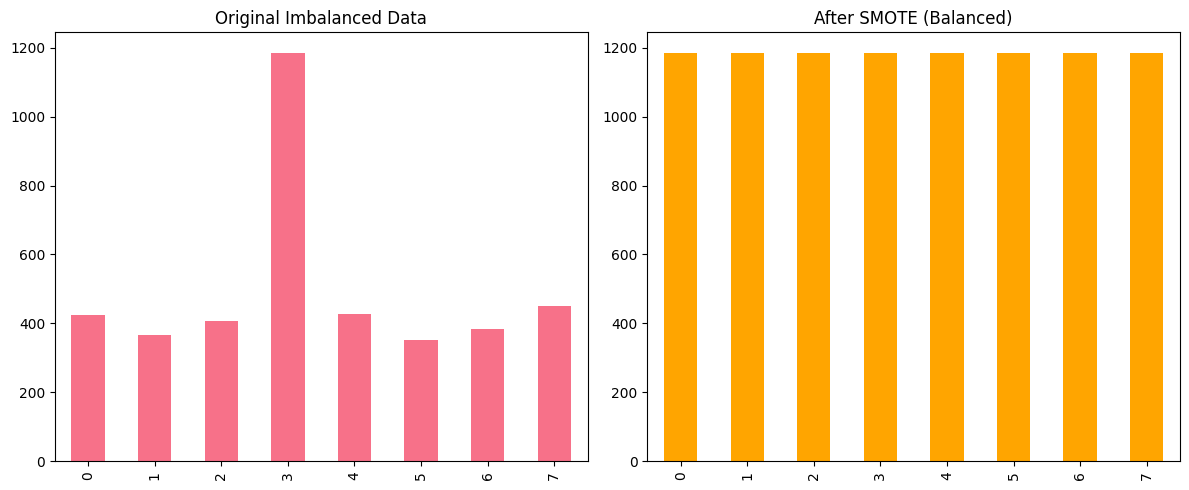

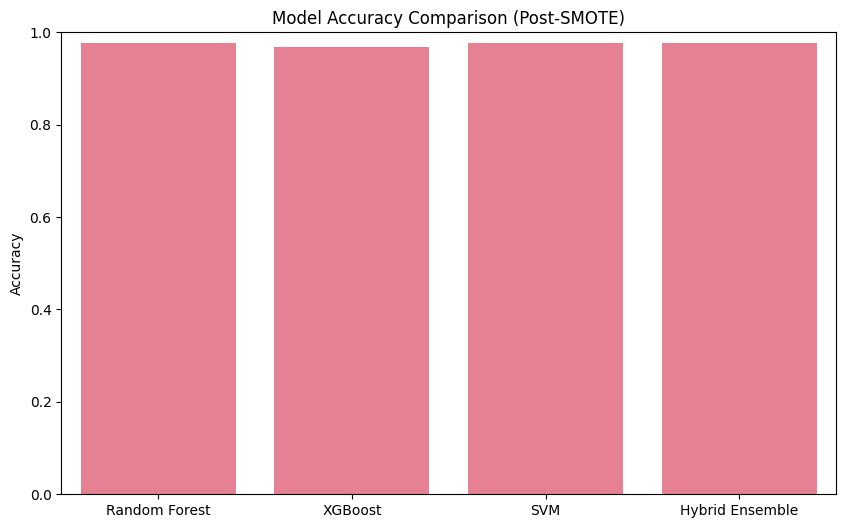

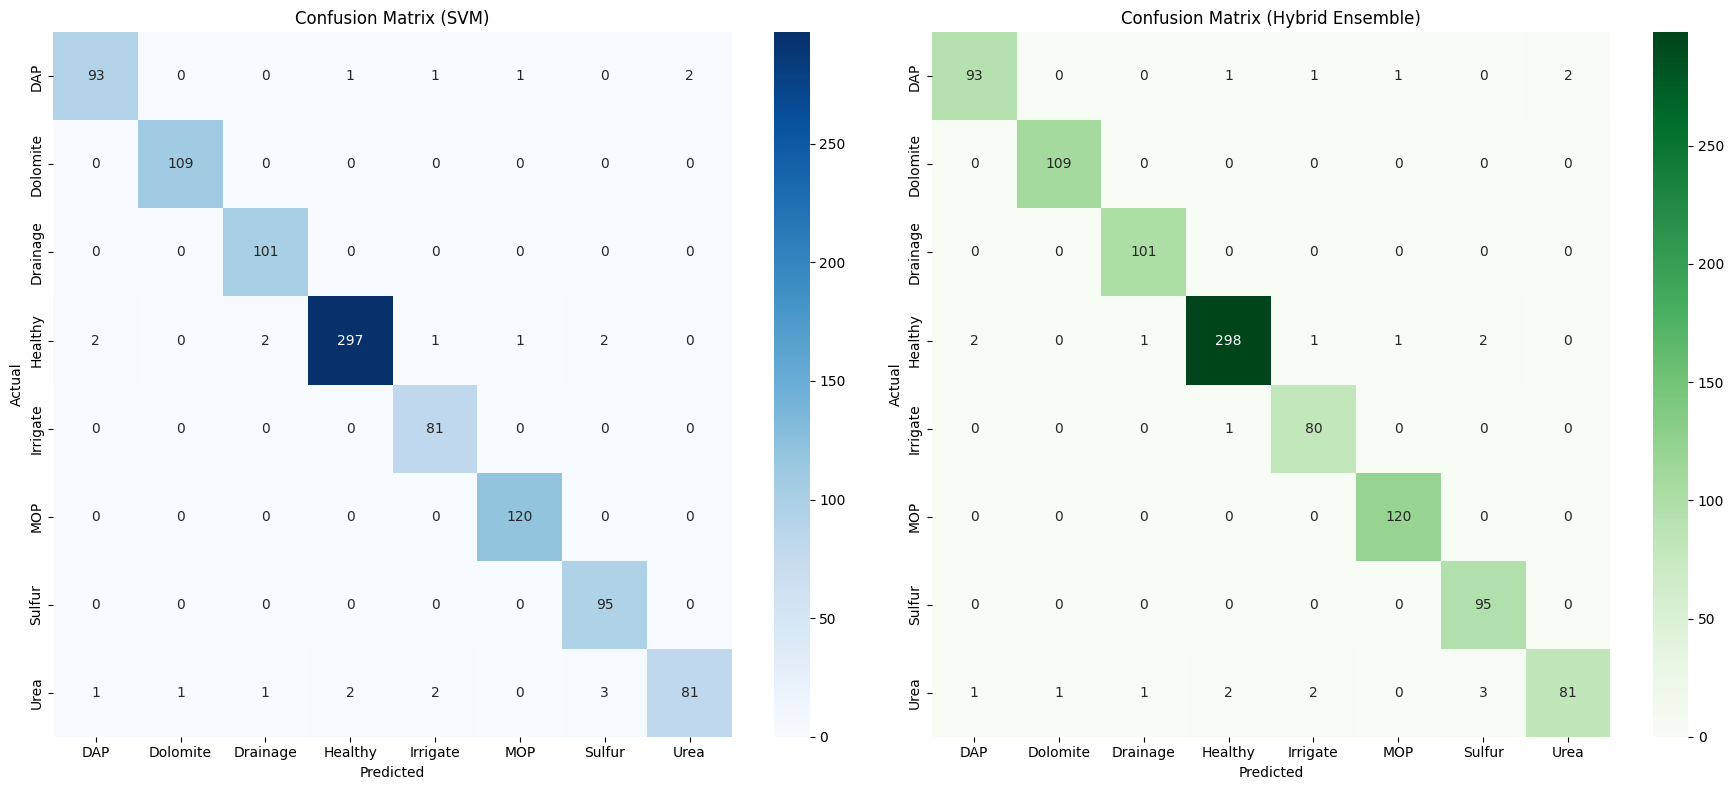

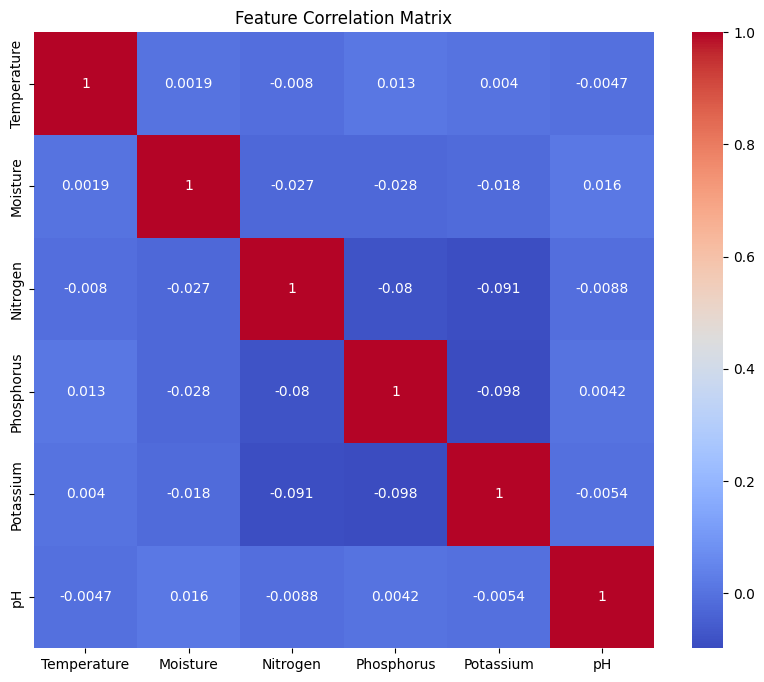

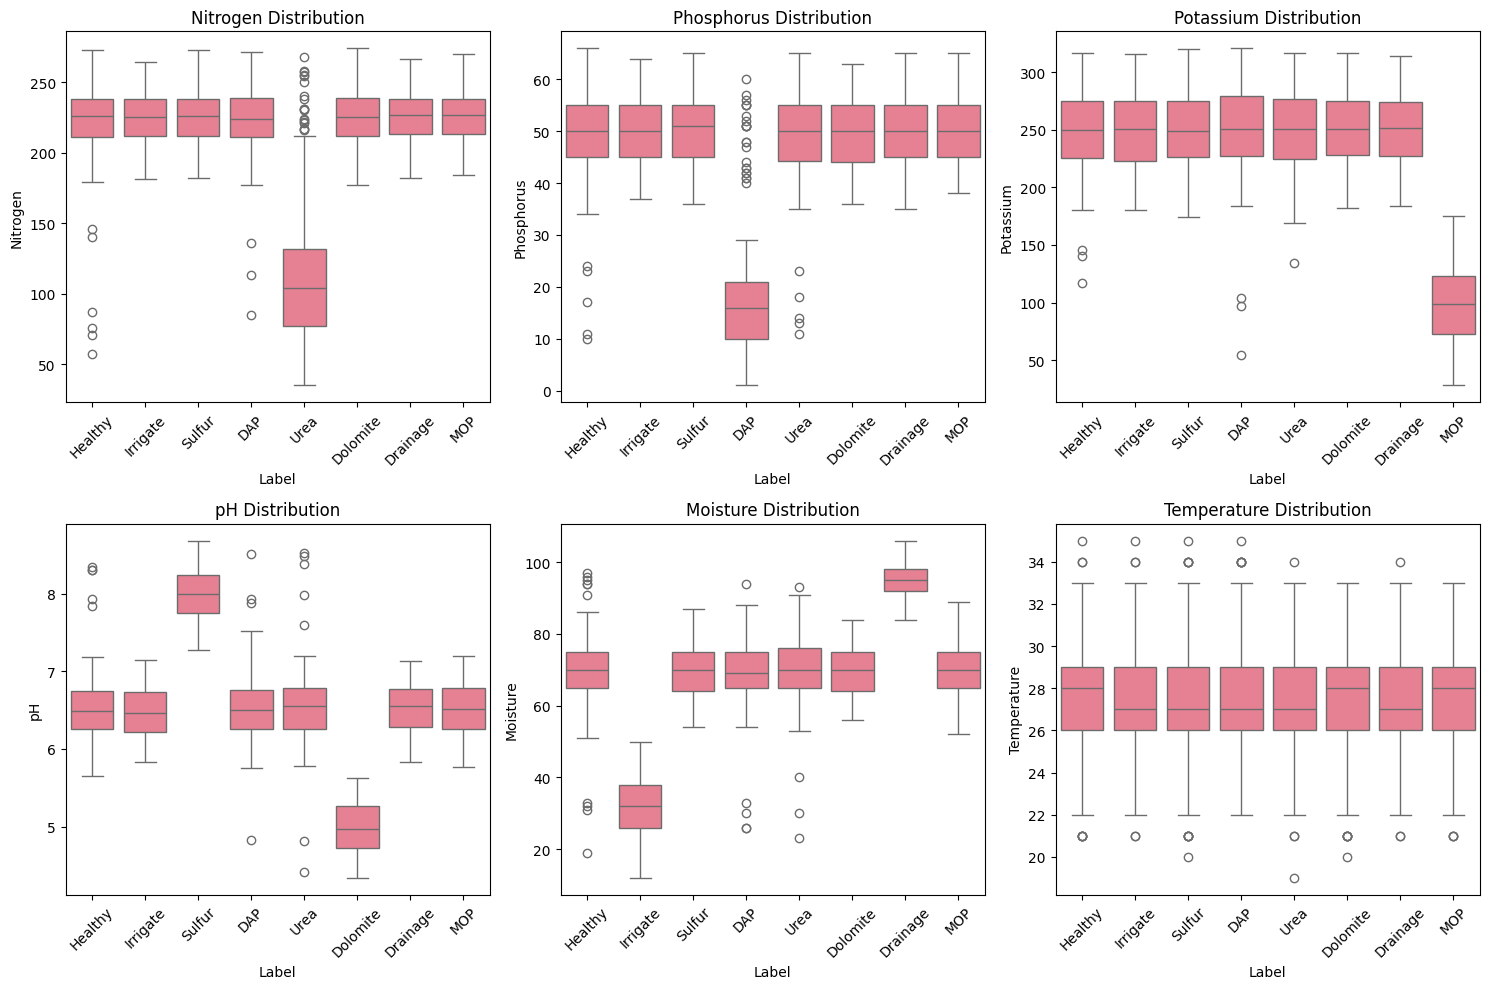

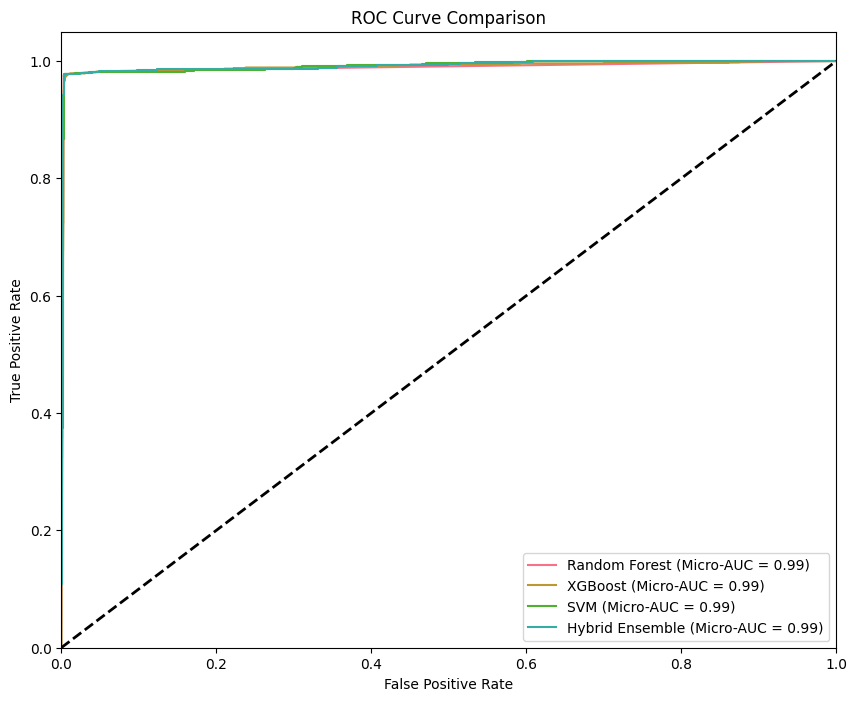


🔧 Tuning Hyperparameters for Random Forest...
   ✅ Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
   ✅ Best Tuned Accuracy: 98.84%

🎉 Process Complete! Models saved in 'model_results_smote'.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import warnings
from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# CONFIGURATION
DATA_FILE = "realistic_soil_data.csv"
OUTPUT_FOLDER = "model_results_smote"

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# ==========================================
# 1. LOADING & PREPROCESSING
# ==========================================
print("🔄 Loading Data...")
df = pd.read_csv(DATA_FILE)

X = df.drop('Label', axis=1)
y = df['Label']

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)

# A. SPLIT DATA (Crucial: Split BEFORE SMOTE to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"   Original Training Count: {Counter(y_train)}")

# B. SCALE DATA (Fit on Train, Transform Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# C. APPLY SMOTE (Fix Imbalance)
print("\n⚖️ Applying SMOTE to fix Class Imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"   New Balanced Training Count: {Counter(y_train_smote)}")
print("   (Notice how all classes now have the same number of samples!)")

# ==========================================
# 2. DEFINE MODELS
# ==========================================
# Define base models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
svm_model = SVC(probability=True, random_state=42)

# Define Hybrid Ensemble (Soft Voting)
hybrid_ensemble = VotingClassifier(
    estimators=[
        ('Random Forest', rf_model),
        ('XGBoost', xgb_model),
        ('SVM', svm_model)
    ],
    voting='soft'
)

# Store all models in a dictionary 
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "SVM": svm_model,
    "Hybrid Ensemble": hybrid_ensemble
}

results = {}
best_model = None
best_score = 0
best_model_name = ""

print("\n🚀 STARTING TRAINING (With SMOTE Data)...")
print("="*60)

# ==========================================
# 3. TRAINING LOOP
# ==========================================
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train on SMOTE Data
    model.fit(X_train_smote, y_train_smote)
    
    # Test on ORIGINAL Test Data (Never test on fake SMOTE data)
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"   ✅ {name} Accuracy: {acc*100:.2f}%")
    print(f"   📊 Precision/Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    if acc > best_score:
        best_score = acc
        best_model = model
        best_model_name = name
        
    # Save Model (replaces spaces with underscores)
    filename_safe_name = name.replace(" ", "_").lower()
    joblib.dump(model, f"{OUTPUT_FOLDER}/{filename_safe_name}_model.pkl")

print("="*60)
print(f"🏆 WINNER: {best_model_name} with {best_score*100:.1f}% Accuracy")

# Save Scaler, Label Encoder and explicitly ensure the Hybrid Ensemble is dumped under a clean name.
joblib.dump(scaler, f"{OUTPUT_FOLDER}/scaler.pkl")
joblib.dump(le, f"{OUTPUT_FOLDER}/label_encoder.pkl")
joblib.dump(hybrid_ensemble, f"{OUTPUT_FOLDER}/hybrid_ensemble_model.pkl")


# ==========================================
# 4. VISUALIZATION GALLERY
# ==========================================
sns.set_palette("husl")

# GRAPH 1: Before vs After SMOTE (Class Distribution)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', title="Original Imbalanced Data")
plt.subplot(1, 2, 2)
pd.Series(y_train_smote).value_counts().sort_index().plot(kind='bar', color='orange', title="After SMOTE (Balanced)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/00_smote_impact.png")
plt.show()

# GRAPH 2: Model Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0.0, 1.0) # Extend bounds for visibility
plt.title("Model Accuracy Comparison (Post-SMOTE)")
plt.ylabel("Accuracy")
plt.savefig(f"{OUTPUT_FOLDER}/01_model_comparison.png")
plt.show()

# GRAPH 3: Confusion Matrix (Hybrid Ensemble & Best Model Comparison)
plt.figure(figsize=(18, 8))

# Subplot for the Best Model
plt.subplot(1, 2, 1)
y_pred_best = best_model.predict(X_test_scaled)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Subplot for the Hybrid Ensemble
plt.subplot(1, 2, 2)
y_pred_ens = hybrid_ensemble.predict(X_test_scaled)
cm_ens = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm_ens, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Greens")
plt.title("Confusion Matrix (Hybrid Ensemble)")
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/03_confusion_matrices.png")
plt.show()

# GRAPH 4: Feature Correlation
plt.figure(figsize=(10, 8))
# Ensure we only calculate correlation on numeric columns 
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.savefig(f"{OUTPUT_FOLDER}/02_correlation.png")
plt.show()

# GRAPHS 5-10: Boxplots
features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Moisture', 'Temperature']
# Make sure we don't index properties that do not exist in df
valid_features = [col for col in features if col in df.columns]

if valid_features:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(valid_features):
        plt.subplot(2, 3, i+1)
        sns.boxplot(x='Label', y=col, data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FOLDER}/04_feature_distributions.png")
    plt.show()

# GRAPH 11: Feature Importance
if best_model_name in ["Random Forest", "XGBoost"]:
    plt.figure(figsize=(10, 6))
    importances = best_model.feature_importances_
    sns.barplot(x=importances, y=X.columns)
    plt.title(f"Feature Importance ({best_model_name})")
    plt.savefig(f"{OUTPUT_FOLDER}/05_feature_importance.png")
    plt.show()

# GRAPH 12: ROC Curve (Micro-Averaged for Multi-Class Compatibility)
plt.figure(figsize=(10, 8))
# Multi-class environments require binarization
if n_classes > 2:
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
else:
    y_test_bin = y_test

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
        
        if n_classes > 2:
            fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        else:
            fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
            
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (Micro-AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.savefig(f"{OUTPUT_FOLDER}/06_roc_curve.png")
plt.show()

# ==========================================
# 5. HYPERPARAMETER TUNING (Random Forest)
# ==========================================
print("\n🔧 Tuning Hyperparameters for Random Forest...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
# Note: Fit GridSearch on the SMOTE data!
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train_smote, y_train_smote)

print(f"   ✅ Best Params: {grid_search.best_params_}")
print(f"   ✅ Best Tuned Accuracy: {grid_search.best_score_*100:.2f}%")

joblib.dump(grid_search.best_estimator_, f"{OUTPUT_FOLDER}/best_tuned_model.pkl")
print(f"\n🎉 Process Complete! Models saved in '{OUTPUT_FOLDER}'.")
